# Bond Pricing and Analytics

This notebook covers the core fixed-income building blocks in the `neon` library:

- **Bond pricing** — dirty price, clean price, accrued interest, and yield-to-maturity (YTM)
- **Bond analytics** — DV01, modified duration, Macaulay duration, and convexity
- **ZeroCouponBond** — a zero-coupon variant of `Bond` (coupon rate = 0)
- **FloatingRateNote** — a floating-rate bond whose coupon equals `reference_rate + spread`

## Key concepts

| Term | Definition |
|---|---|
| **Dirty price** | Full present value of all future cash flows discounted at the YTM. |
| **Clean price** | Dirty price minus accrued interest — the quoted market price. |
| **Accrued interest** | Coupon earned since the last payment date but not yet paid. |
| **YTM** | The single discount rate that equates the dirty price to the PV of all cash flows. |

A bond priced *at par* (clean price = face) has YTM equal to its coupon rate.  
When yields rise, prices fall (and vice versa) — this inverse relationship is captured by duration and convexity.

In [1]:
from neon.lib.fixed_income.bond import Bond
from neon.lib.fixed_income.bond_analytics import BondAnalytics
from neon.lib.fixed_income.zero_coupon_bond import ZeroCouponBond
from neon.lib.fixed_income.frn import FloatingRateNote
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

print('All imports OK')

All imports OK


## 1. Bond Pricing

We create a 10-year, semi-annual 5 % coupon bond issued and settled on 2025-01-01, maturing 2035-01-01.

When the YTM equals the coupon rate the bond prices at par (clean price ≈ 100).

In [2]:
ISSUE  = '20250101'
SETTLE = '20250101'
MAT    = '20350101'
YTM    = 0.05

bond = Bond(
    issue_date=ISSUE,
    maturity_date=MAT,
    coupon_rate=0.05,
    coupon_freq=2,
    face=100.0,
)

dirty = bond.dirty_price_from_ytm(SETTLE, YTM)
clean = bond.clean_price_from_ytm(SETTLE, YTM)
ai    = bond.accrued_interest(SETTLE)

# YTM round-trip: recover yield from clean price
ytm_rt = bond.yield_to_maturity(SETTLE, clean)

print(f'Dirty price        : {dirty:.6f}')
print(f'Clean price        : {clean:.6f}')
print(f'Accrued interest   : {ai:.6f}')
print(f'YTM (round-trip)   : {ytm_rt:.6f}  (expected 0.050000)')
print(f'Round-trip error   : {abs(ytm_rt - YTM):.2e}')

Dirty price        : 100.000000
Clean price        : 100.000000
Accrued interest   : 0.000000
YTM (round-trip)   : 0.050000  (expected 0.050000)
Round-trip error   : 5.07e-15


## 2. Bond Analytics

`BondAnalytics` computes risk measures via ±1 bp bump-and-reprice:

| Measure | Formula | Unit |
|---|---|---|
| **DV01** | (P(y−1bp) − P(y+1bp)) / 2 | $ per $100 face |
| **Modified duration** | DV01 / P × 10 000 | years |
| **Macaulay duration** | ModDur × (1 + y/freq) | years |
| **Convexity** | (P↑ + P↓ − 2P) / (P × Δy²) | years² |

In [3]:
analytics = BondAnalytics(bond)

dv01     = analytics.dv01(SETTLE, YTM)
mod_dur  = analytics.modified_duration(SETTLE, YTM)
mac_dur  = analytics.macaulay_duration(SETTLE, YTM)
convex   = analytics.convexity(SETTLE, YTM)

print(f'DV01               : {dv01:.6f}   ($ per $100 face per 1bp)')
print(f'Modified duration  : {mod_dur:.4f} years')
print(f'Macaulay duration  : {mac_dur:.4f} years')
print(f'Convexity          : {convex:.4f}')

# Approximate price change for a +50bp shift using duration + convexity
dy = 0.005
dp_approx = -mod_dur * dirty * dy + 0.5 * convex * dirty * dy**2
dp_exact  = bond.dirty_price_from_ytm(SETTLE, YTM + dy) - dirty
print(f'\n+50bp price change — exact: {dp_exact:.4f}, approx: {dp_approx:.4f}')

DV01               : 0.077946   ($ per $100 face per 1bp)
Modified duration  : 7.7946 years
Macaulay duration  : 7.9894 years
Convexity          : 73.6287

+50bp price change — exact: -3.8068, approx: -3.8053


## 3. Zero Coupon Bond

A zero-coupon bond pays no coupons — only face value at maturity.  
Its price is simply `face / (1 + y)^T` and it exhibits the highest duration for a given maturity.

In [4]:
zcb = ZeroCouponBond(issue_date=ISSUE, maturity_date=MAT)

zcb_dirty = zcb.dirty_price_from_ytm(SETTLE, YTM)
zcb_clean = zcb.clean_price_from_ytm(SETTLE, YTM)
zcb_ai    = zcb.accrued_interest(SETTLE)

# Duration of a ZCB equals its maturity
zcb_analytics = BondAnalytics(zcb)
zcb_mac_dur   = zcb_analytics.macaulay_duration(SETTLE, YTM)

print(f'ZCB dirty price      : {zcb_dirty:.4f}')
print(f'ZCB clean price      : {zcb_clean:.4f}')
print(f'ZCB accrued interest : {zcb_ai:.4f}')
print(f'ZCB Macaulay duration: {zcb_mac_dur:.4f} years  (≈ 10y for a zero-coupon bond)')

ZCB dirty price      : 61.3913
ZCB clean price      : 61.3913
ZCB accrued interest : 0.0000
ZCB Macaulay duration: 10.0000 years  (≈ 10y for a zero-coupon bond)


## 4. Floating Rate Note

A floating-rate note (FRN) resets its coupon each period to `reference_rate + spread`.  
The `neon` FRN treats the coupon as fixed at `reference_rate + spread` for pricing purposes (a snapshot of the current reset).  
Here we use `reference_rate=0.04` and `spread=0.01`, giving an effective coupon of 5 %.

In [5]:
frn = FloatingRateNote(
    issue_date=ISSUE,
    maturity_date=MAT,
    reference_rate=0.04,
    spread=0.01,
    coupon_freq=2,
)

frn_coupon = frn._coupon_rate
frn_dirty  = frn.dirty_price_from_ytm(SETTLE, YTM)
frn_clean  = frn.clean_price_from_ytm(SETTLE, YTM)
frn_ai     = frn.accrued_interest(SETTLE)

print(f'FRN effective coupon rate : {frn_coupon:.2%}  (ref 4% + spread 1%)')
print(f'FRN dirty price           : {frn_dirty:.4f}')
print(f'FRN clean price           : {frn_clean:.4f}')
print(f'FRN accrued interest      : {frn_ai:.4f}')
print()
# Compare with vanilla bond of same coupon
print(f'Vanilla bond clean price  : {clean:.4f}')
print(f'Difference                : {abs(frn_clean - clean):.2e}  (should be ~0)')

FRN effective coupon rate : 5.00%  (ref 4% + spread 1%)
FRN dirty price           : 100.0000
FRN clean price           : 100.0000
FRN accrued interest      : 0.0000

Vanilla bond clean price  : 100.0000
Difference                : 0.00e+00  (should be ~0)


## 5. Bond Price vs YTM

The price-yield relationship is convex — the price falls faster when yields are low and slower when yields are high.  
We also plot the ZCB price for comparison: the ZCB is more sensitive to yield changes because its entire cash flow is deferred to maturity.

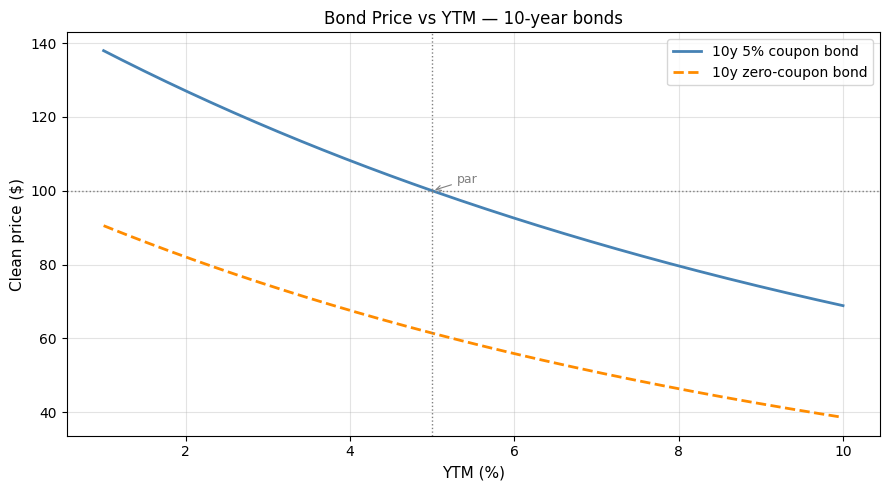

In [6]:
ytm_range = np.linspace(0.01, 0.10, 200)

prices_bond = [bond.clean_price_from_ytm(SETTLE, y) for y in ytm_range]
prices_zcb  = [zcb.clean_price_from_ytm(SETTLE, y) for y in ytm_range]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(ytm_range * 100, prices_bond, color='steelblue', linewidth=2,
        label='10y 5% coupon bond')
ax.plot(ytm_range * 100, prices_zcb, color='darkorange', linewidth=2,
        linestyle='--', label='10y zero-coupon bond')

ax.axvline(5.0, color='grey', linestyle=':', linewidth=1)
ax.axhline(100.0, color='grey', linestyle=':', linewidth=1)
ax.annotate('par', xy=(5.0, 100.0), xytext=(5.3, 102),
            fontsize=9, color='grey',
            arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))

ax.set_xlabel('YTM (%)', fontsize=11)
ax.set_ylabel('Clean price ($)', fontsize=11)
ax.set_title('Bond Price vs YTM — 10-year bonds', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

## 6. Duration and Convexity vs YTM

Both modified duration and convexity decrease as yields rise — the bond becomes less sensitive to further yield moves.

Convexity is always positive for a plain vanilla bond: this means the duration-only approximation of price change **understates** the actual price for both yield increases and decreases (i.e., convexity is always a benefit to the bondholder).

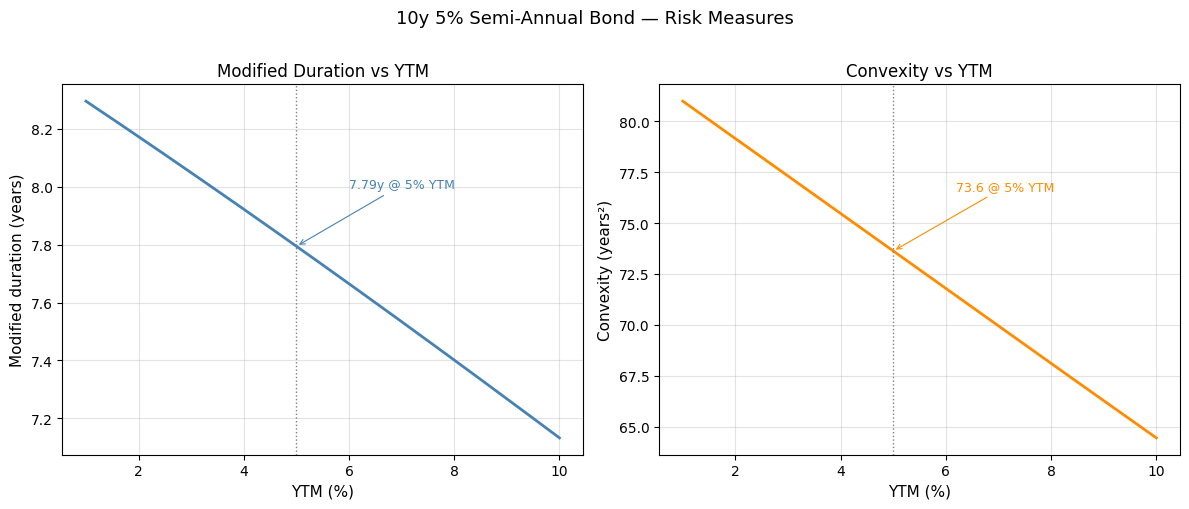

In [7]:
mod_durs = [analytics.modified_duration(SETTLE, y) for y in ytm_range]
convexs  = [analytics.convexity(SETTLE, y) for y in ytm_range]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Modified duration ---
ax1.plot(ytm_range * 100, mod_durs, color='steelblue', linewidth=2)
ax1.axvline(5.0, color='grey', linestyle=':', linewidth=1)
ax1.set_xlabel('YTM (%)', fontsize=11)
ax1.set_ylabel('Modified duration (years)', fontsize=11)
ax1.set_title('Modified Duration vs YTM', fontsize=12)
ax1.grid(True, alpha=0.35)

# Annotate value at par yield
dur_at_par = analytics.modified_duration(SETTLE, YTM)
ax1.annotate(f'{dur_at_par:.2f}y @ 5% YTM',
             xy=(5.0, dur_at_par), xytext=(6.0, dur_at_par + 0.2),
             fontsize=9, color='steelblue',
             arrowprops=dict(arrowstyle='->', color='steelblue', lw=0.8))

# --- Convexity ---
ax2.plot(ytm_range * 100, convexs, color='darkorange', linewidth=2)
ax2.axvline(5.0, color='grey', linestyle=':', linewidth=1)
ax2.set_xlabel('YTM (%)', fontsize=11)
ax2.set_ylabel('Convexity (years²)', fontsize=11)
ax2.set_title('Convexity vs YTM', fontsize=12)
ax2.grid(True, alpha=0.35)

# Annotate value at par yield
conv_at_par = analytics.convexity(SETTLE, YTM)
ax2.annotate(f'{conv_at_par:.1f} @ 5% YTM',
             xy=(5.0, conv_at_par), xytext=(6.2, conv_at_par + 3),
             fontsize=9, color='darkorange',
             arrowprops=dict(arrowstyle='->', color='darkorange', lw=0.8))

plt.suptitle('10y 5% Semi-Annual Bond — Risk Measures', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()